# Face Recognition with PCA
**ORL/ATT Dataset — 40 subjects × 10 images each**

## 1. Imports

In [1]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from PIL import Image
from scipy.special import logsumexp
from scipy.stats import mode
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
np.random.seed(SEED)
random.seed(SEED)


## 2. Load Dataset → Data Matrix D and Label Vector y

In [2]:
base_path = kagglehub.dataset_download("kasikrit/att-database-of-faces")

if os.path.exists(os.path.join(base_path, "s1")):
    DATASET_PATH = base_path
else:
    DATASET_PATH = os.path.join(base_path, "files")

IMG_H, IMG_W = 112, 92
N_FEATURES   = IMG_H * IMG_W
N_SUBJECTS  = 40
N_PER_SUBJ  = 10

D = np.zeros((N_SUBJECTS * N_PER_SUBJ, IMG_H * IMG_W), dtype=np.float64)
y = np.zeros(N_SUBJECTS * N_PER_SUBJ, dtype=np.int32)

row = 0
for subject_id in range(1, N_SUBJECTS + 1):
    subject_dir = os.path.join(DATASET_PATH, f"s{subject_id}")

    for img_idx in range(1, N_PER_SUBJ + 1):
        img_path = os.path.join(subject_dir, f"{img_idx}.pgm")

        with Image.open(img_path) as img:
            img = img.convert("L")  # grayscale
            D[row] = np.array(img, dtype=np.float64).flatten()
            y[row] = subject_id
            row += 1

print(f"Data matrix shape : {D.shape}")
print(f"Label vector shape: {y.shape}")
print(f"Label range       : {y.min()} – {y.max()}")

Using Colab cache for faster access to the 'att-database-of-faces' dataset.
Data matrix shape : (400, 10304)
Label vector shape: (400,)
Label range       : 1 – 40


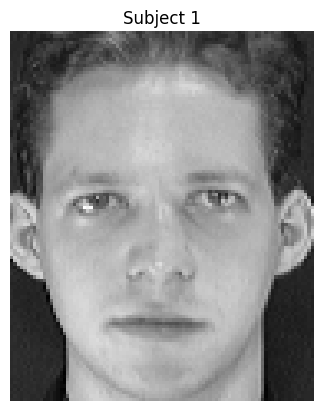

In [3]:
plt.imshow(D[0].reshape(112, 92), cmap='gray')
plt.title(f"Subject {y[0]}")
plt.axis('off')
plt.show()

## 3. Train / Test Split (odd rows → train, even rows → test)

In [4]:
train_idx = []
test_idx  = []

for subject_id in range(N_SUBJECTS):
    base = subject_id * N_PER_SUBJ
    for i in range(N_PER_SUBJ):
        if (i + 1) % 2 == 1:   # odd
            train_idx.append(base + i)
        else:                   # even
            test_idx.append(base + i)

X_train, y_train = D[train_idx], y[train_idx]
X_test,  y_test  = D[test_idx],  y[test_idx]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (200, 10304), Test: (200, 10304)


## 4. PCA Implementation (from scratch)

Steps:
1. Compute the mean face from the **training** set.
2. Center the data.
3. Compute the covariance matrix (using the trick for high-dimensional data).
4. Compute eigenvalues / eigenvectors.
5. Save eigenvalues to `.npy` for reuse.

In [5]:
EIGEN_CACHE = 'pca_eigen_cache.npz'

def compute_pca(X: np.ndarray, cache_path: str = None):
    if cache_path and os.path.exists(cache_path):
        print(f'Loading cached PCA from {cache_path} …')
        data = np.load(cache_path)
        return data['mean'], data['eigenvalues'], data['eigenvectors']

    print('Computing PCA (this may take a moment) …')
    n, d = X.shape
    mean = X.mean(axis=0)                          # (d,)
    X_c  = X - mean                                # centered  (n × d)

    # Small covariance trick: compute n×n matrix
    C_small = (X_c @ X_c.T) / (n - 1)             # (n × n)
    vals, vecs_small = np.linalg.eigh(C_small)     # ascending order

    # Map eigenvectors back to d-dimensional space
    eigvecs = X_c.T @ vecs_small                   # (d × n)

    # Normalise each column
    norms = np.linalg.norm(eigvecs, axis=0, keepdims=True)
    norms[norms == 0] = 1
    eigvecs = eigvecs / norms                      # (d × n)

    # Sort descending
    order   = np.argsort(vals)[::-1]
    vals    = vals[order]
    eigvecs = eigvecs[:, order]                    # (d × n)

    if cache_path:
        np.savez(cache_path, mean=mean, eigenvalues=vals, eigenvectors=eigvecs)
        print(f'Cached to {cache_path}')

    return mean, vals, eigvecs


pca_mean, pca_eigenvalues, pca_eigenvectors = compute_pca(X_train, EIGEN_CACHE)
print(f'Eigenvalues shape : {pca_eigenvalues.shape}')
print(f'Eigenvectors shape: {pca_eigenvectors.shape}')

Computing PCA (this may take a moment) …
Cached to pca_eigen_cache.npz
Eigenvalues shape : (200,)
Eigenvectors shape: (10304, 200)


## 5. Variance Retention & Dimensionality per α

In [6]:
alphas = [0.80, 0.85, 0.90, 0.95]

cumvar = np.cumsum(pca_eigenvalues) / np.sum(pca_eigenvalues)

print(f"{'α':>6}  {'k (components)':>16}  {'Variance retained':>20}")
print("-" * 45)
k_per_alpha = {}
for alpha in alphas:
    k = int(np.searchsorted(cumvar, alpha)) + 1
    k_per_alpha[alpha] = k
    retained = cumvar[k - 1] * 100
    print(f"{alpha:>6.2f}  {k:>6}  {retained:>19.2f}%")

     α    k (components)     Variance retained
---------------------------------------------
  0.80      36                80.36%
  0.85      51                85.06%
  0.90      76                90.13%
  0.95     115                95.01%


## 6. Project Data into PCA Subspace (all α values)

In [7]:
def pca_project(X, mean_face, eigenvectors, k):
    """Center X and project onto the first k eigenvectors."""
    X_c = X - mean_face
    return X_c @ eigenvectors[:, :k]   #(n_samples, k)

projections = {}
for alpha in alphas:
    k = k_per_alpha[alpha]
    projections[alpha] = {
        "k"       : k,
        "train"   : pca_project(X_train, pca_mean, pca_eigenvectors, k),
        "test"    : pca_project(X_test,  pca_mean, pca_eigenvectors, k),
    }
    print(f"α={alpha}  k={k:3d}  train_proj={projections[alpha]['train'].shape}  test_proj={projections[alpha]['test'].shape}")

α=0.8  k= 36  train_proj=(200, 36)  test_proj=(200, 36)
α=0.85  k= 51  train_proj=(200, 51)  test_proj=(200, 51)
α=0.9  k= 76  train_proj=(200, 76)  test_proj=(200, 76)
α=0.95  k=115  train_proj=(200, 115)  test_proj=(200, 115)


## 7. Visualise Sample Faces Reconstructed from PCA Subspace

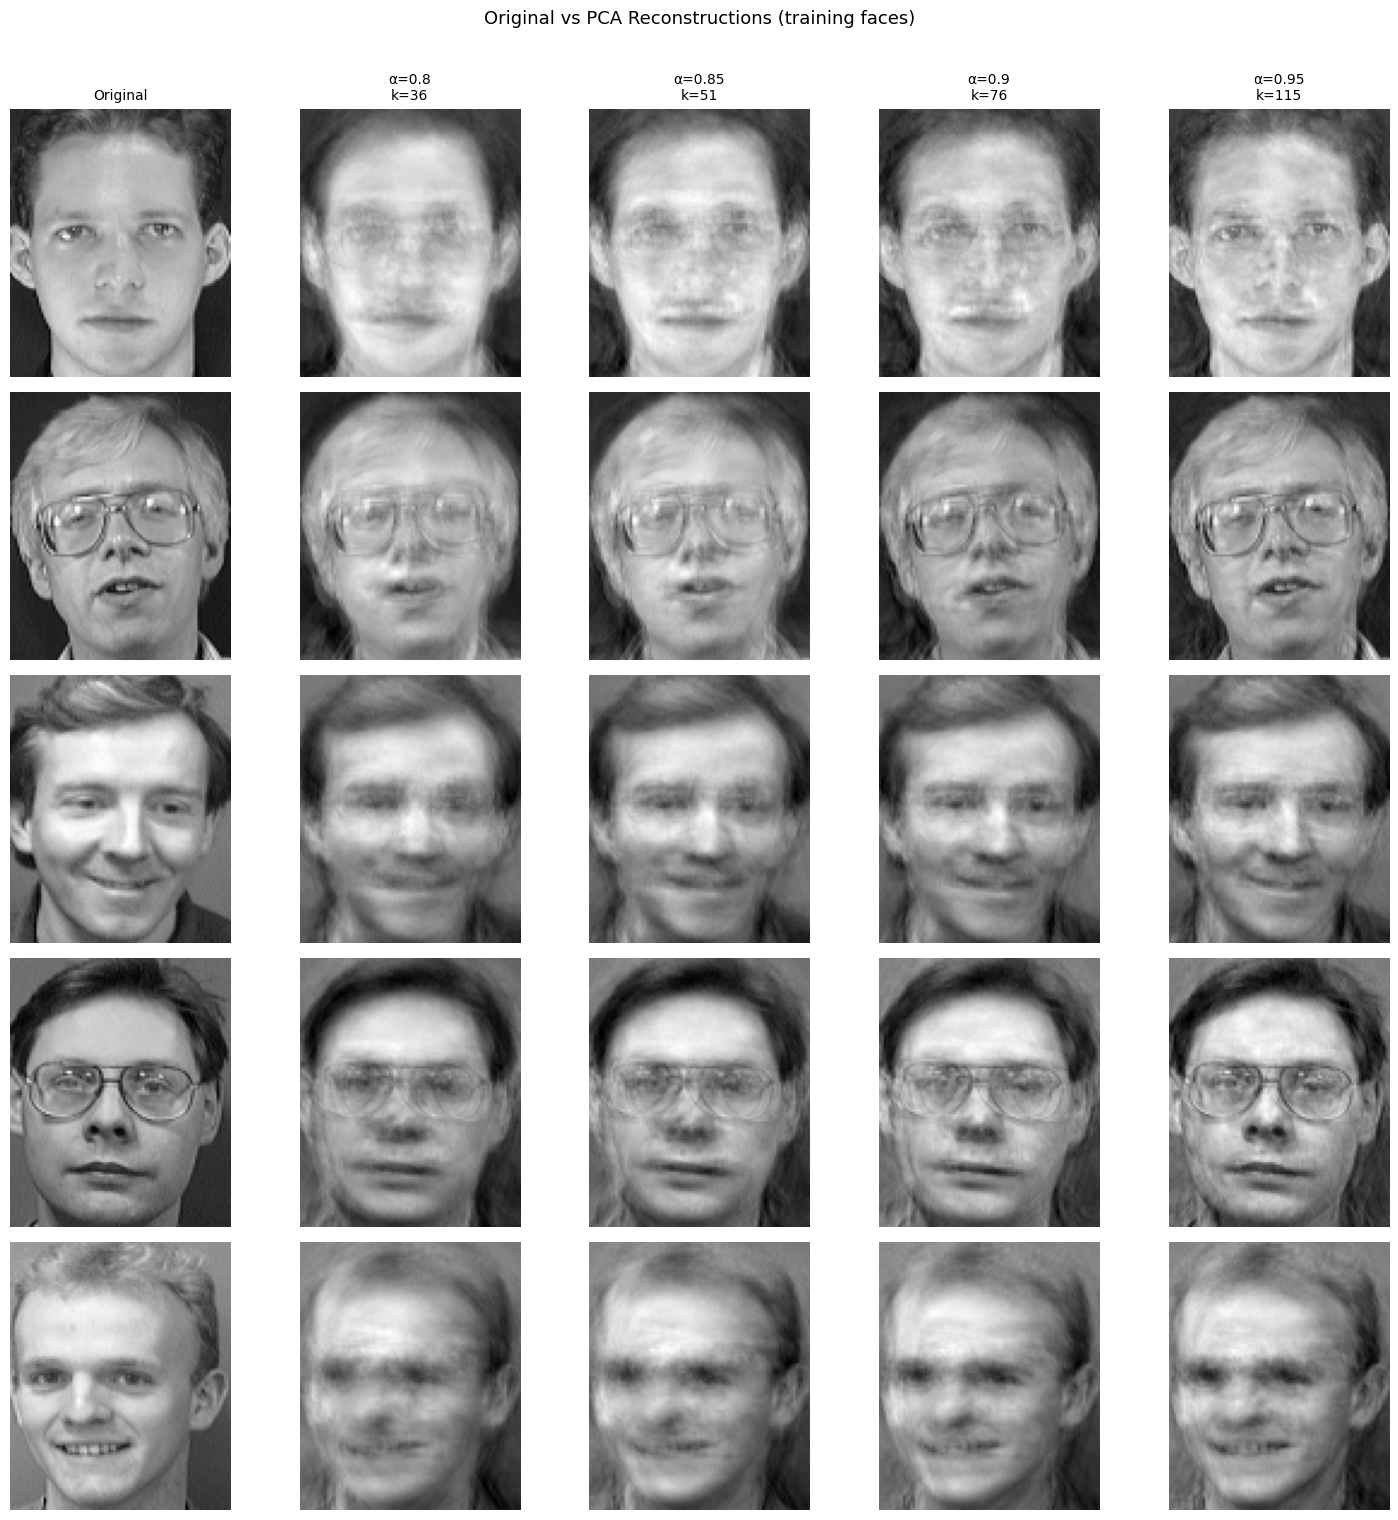

In [8]:
def reconstruct(proj, mean_face, eigenvectors):
    """Reconstruct faces from PCA projection."""
    k = proj.shape[1]
    return proj @ eigenvectors[:, :k].T + mean_face

N_SHOW = 5   # number of sample subjects to show
sample_rows = [i * N_PER_SUBJ // 2 for i in range(N_SHOW)]   # one image per subject from train

fig, axes = plt.subplots(N_SHOW, len(alphas) + 1,
                         figsize=(3 * (len(alphas) + 1), 3 * N_SHOW))

for row_i, row_idx in enumerate(sample_rows):
    # Original
    ax = axes[row_i, 0]
    ax.imshow(X_train[row_idx].reshape(IMG_H, IMG_W), cmap="gray")
    ax.axis("off")
    if row_i == 0:
        ax.set_title("Original", fontsize=10)

    # Reconstructions
    for col_i, alpha in enumerate(alphas):
        k    = projections[alpha]["k"]
        proj = projections[alpha]["train"][row_idx:row_idx+1]

        rec  = reconstruct(proj, pca_mean, pca_eigenvectors)[0]
        ax   = axes[row_i, col_i + 1]
        ax.imshow(rec.reshape(IMG_H, IMG_W), cmap="gray")
        ax.axis("off")
        if row_i == 0:
            ax.set_title(f"α={alpha}\nk={k}", fontsize=10)

plt.suptitle("Original vs PCA Reconstructions (training faces)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Visualise the Mean Face and Top Eigenfaces

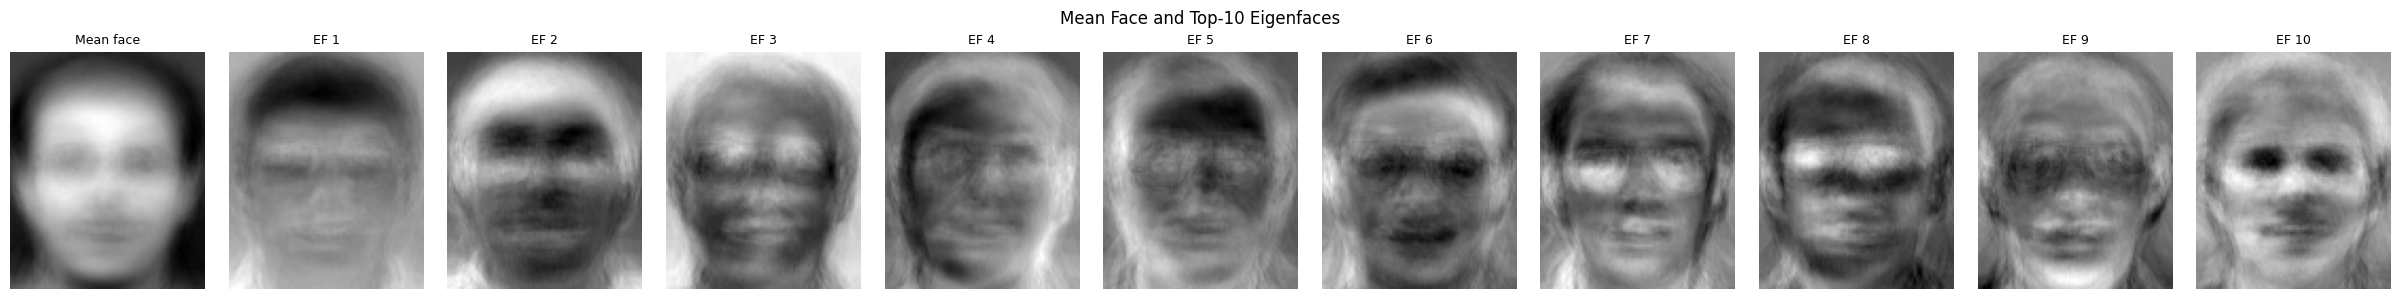

In [9]:
N_EIGENFACES = 10
fig, axes = plt.subplots(1, N_EIGENFACES + 1, figsize=(2.2 * (N_EIGENFACES + 1), 3))

axes[0].imshow(pca_mean.reshape(IMG_H, IMG_W), cmap="gray")
axes[0].set_title("Mean face", fontsize=9)
axes[0].axis("off")

for i in range(N_EIGENFACES):
    ef = pca_eigenvectors[:, i].reshape(IMG_H, IMG_W)
    axes[i + 1].imshow(ef, cmap="gray")
    axes[i + 1].set_title(f"EF {i+1}", fontsize=9)
    axes[i + 1].axis("off")

plt.suptitle("Mean Face and Top-10 Eigenfaces", fontsize=12)
plt.tight_layout()
plt.show()

---
## K-Means Clustering

### Implementation

In [10]:
def kmeans_fit(X, K, max_iter=100, tol=1e-4, random_state=None):
    rng = np.random.default_rng(random_state)
    n = X.shape[0]

    centroids = X[rng.choice(n, K, replace=False)].copy()
    labels = np.zeros(n, dtype=int)

    for _ in range(max_iter):
        diff = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]
        distances = np.sum(diff ** 2, axis=2)
        labels = np.argmin(distances, axis=1)

        new_centroids = np.zeros_like(centroids)

        for k in range(K):
            points = X[labels == k]

            if len(points) > 0:
                new_centroids[k] = points.mean(axis=0)
            else:
                # keep old centroid if cluster is empty
                new_centroids[k] = centroids[k]

        shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids

        if shift < tol:
            break

    return centroids, labels

Prediction

In [11]:
def kmeans_predict(X, centroids):
    diff = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]
    distances = np.sum(diff ** 2, axis=2)
    return np.argmin(distances, axis=1)

Clustering Accuracy

In [12]:
def clustering_accuracy(y_true: np.ndarray, cluster_labels: np.ndarray) -> float:
    """
    Map each cluster to its most common true label (majority vote),
    then compute accuracy.
    """
    y_pred = np.zeros_like(y_true)
    for cluster_id in np.unique(cluster_labels):
        mask     = cluster_labels == cluster_id
        majority = mode(y_true[mask], keepdims=True).mode[0]
        y_pred[mask] = majority
    return accuracy_score(y_true, y_pred)


def map_clusters_to_labels(y_true: np.ndarray,
                           cluster_labels: np.ndarray,
                           n_clusters: int) -> dict:
    """Return dict: cluster_id → majority true label."""
    mapping = {}
    for k in range(n_clusters):
        mask = cluster_labels == k
        if mask.sum() == 0:
            mapping[k] = -1
        else:
            mapping[k] = mode(y_true[mask], keepdims=True).mode[0]
    return mapping


In [13]:
K_VALUES = [20, 40, 60]
km_results = {a: {} for a in alphas}
best_km_alpha, best_km_K, best_km_acc = None, None, -1

print(f"{'Alpha':>6}  {'K':>4}  {'Dims':>5}  {'Train Acc':>10}")
print("-" * 40)

for alpha in alphas:
    X_tr = projections[alpha]["train"]
    for K in K_VALUES:
        centroids, train_labels = kmeans_fit(X_tr, K, max_iter=100, random_state=SEED)
        train_acc = clustering_accuracy(y_train, train_labels)

        km_results[alpha][K] = {
            "centroids": centroids,
            "train_acc": train_acc
        }

        if train_acc > best_km_acc:
            best_km_acc   = train_acc
            best_km_alpha = alpha
            best_km_K     = K

        print(f"{alpha:>6.2f}  {K:>4d}  {projections[alpha]['k']:>5d}  "
              f"{train_acc:>10.4f}")

print(f"\nBest K-Means config: alpha={best_km_alpha}, K={best_km_K}, train_acc={best_km_acc:.4f}")


 Alpha     K   Dims   Train Acc
----------------------------------------
  0.80    20     36      0.4550
  0.80    40     36      0.6400
  0.80    60     36      0.8200
  0.85    20     51      0.4250
  0.85    40     51      0.7000
  0.85    60     51      0.8050
  0.90    20     76      0.4150
  0.90    40     76      0.6350
  0.90    60     76      0.8000
  0.95    20    115      0.4250
  0.95    40    115      0.6550
  0.95    60    115      0.7600

Best K-Means config: alpha=0.8, K=60, train_acc=0.8200


Accuracy vs K

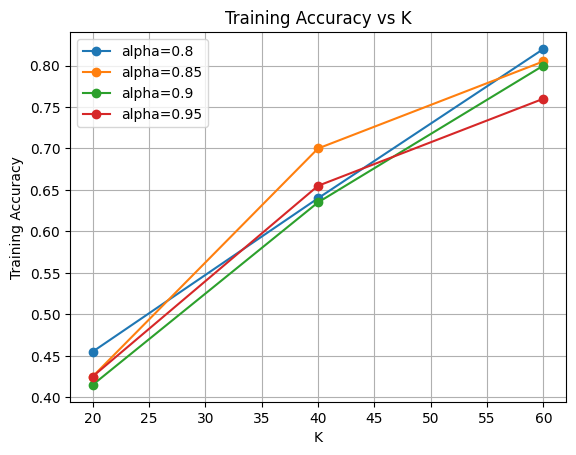

In [14]:
plt.figure()

for alpha in alphas:
    ks = []
    accs = []

    for K in K_VALUES:
        ks.append(K)
        accs.append(km_results[alpha][K]["train_acc"])

    plt.plot(ks, accs, marker='o', label=f'alpha={alpha}')

plt.xlabel("K")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs K")
plt.legend()
plt.grid(True)
plt.show()

Accuracy vs Alpha

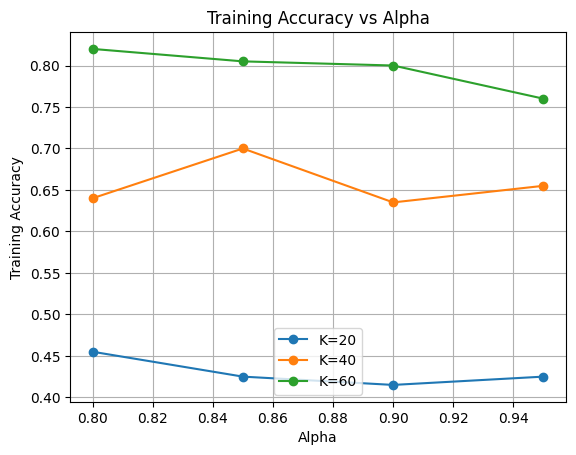

In [15]:
plt.figure()

for K in K_VALUES:
    alpha_list = []
    accs = []

    for alpha in alphas:
        alpha_list.append(alpha)
        accs.append(km_results[alpha][K]["train_acc"])

    plt.plot(alpha_list, accs, marker='o', label=f'K={K}')

plt.xlabel("Alpha")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs Alpha")
plt.legend()
plt.grid(True)
plt.show()

---
## GMM Clustering

### Implementation

In [16]:
def log_gaussian(X, mu, sigma):
    d = X.shape[1]
    diff = X - mu

    sigma_reg = sigma + 1e-6 * np.eye(d)
    sign, logdet = np.linalg.slogdet(sigma_reg)

    # solve instead of inverse (more stable)
    sol = np.linalg.solve(sigma_reg, diff.T).T
    mah2 = np.sum(diff * sol, axis=1)

    log_norm = -0.5 * (d * np.log(2 * np.pi) + logdet)
    log_prob = log_norm - 0.5 * mah2

    return log_prob

def gmm(X, K, iters=100, reg=1e-6):
    n, d = X.shape
    np.random.seed(42)

    # init
    mu = X[np.random.choice(n, K, replace=False)].astype(float)
    sigma = np.array([np.eye(d) for _ in range(K)])
    pi = np.ones(K) / K

    for _ in range(iters):

        # E-step (log responsibilities)
        log_r = np.zeros((n, K))

        for k in range(K):
            log_r[:, k] = np.log(pi[k] + 1e-300) + log_gaussian(X, mu[k], sigma[k])

        # stable normalization
        log_r -= logsumexp(log_r, axis=1, keepdims=True)
        r = np.exp(log_r)

        # M-step
        Nk = r.sum(axis=0) + 1e-12

        for k in range(K):
            mu[k] = (r[:, k:k+1] * X).sum(axis=0) / Nk[k]

            diff = X - mu[k]
            sigma[k] = (r[:, k:k+1] * diff).T @ diff / Nk[k]
            sigma[k] += reg * np.eye(d)

        pi = Nk / n

    labels = np.argmax(r, axis=1)
    return mu, sigma, pi, labels



In [17]:
def predict_gmm(X, mu, sigma, pi):
    n, K = X.shape[0], len(pi)
    log_r = np.zeros((n, K))

    for k in range(K):
        log_r[:, k] = np.log(pi[k] + 1e-300) + log_gaussian(X, mu[k], sigma[k])

    return np.argmax(log_r, axis=1)

In [18]:
gmm_results = {}
best_gmm_alpha, best_gmm_K, best_gmm_acc = None, None, -1

print(f"{'Alpha':>6}  {'K':>4}  {'Dims':>5}  {'Train Acc':>10}")
print("-" * 40)

for alpha in alphas:
    X_tr = projections[alpha]["train"]
    gmm_results[alpha] = {}

    for K in K_VALUES:

        mu, sigma, pi, labels = gmm(X_tr, K)

        train_acc = clustering_accuracy(y_train, labels)

        gmm_results[alpha][K] = {
            "mu": mu,
            "sigma": sigma,
            "pi": pi,
            "train_acc": train_acc
        }

        if train_acc > best_gmm_acc:
            best_gmm_acc = train_acc
            best_gmm_alpha = alpha
            best_gmm_K = K
            best_mu = mu
            best_sigma = sigma
            best_pi = pi

        print(f"{alpha:>6.2f}  {K:>4d}  {projections[alpha]['k']:>5d}  "
              f"{train_acc:>10.4f}")

 Alpha     K   Dims   Train Acc
----------------------------------------
  0.80    20     36      0.3850
  0.80    40     36      0.6350
  0.80    60     36      0.7900
  0.85    20     51      0.3800
  0.85    40     51      0.6300
  0.85    60     51      0.7800
  0.90    20     76      0.3700
  0.90    40     76      0.6250
  0.90    60     76      0.7550
  0.95    20    115      0.3650
  0.95    40    115      0.6100
  0.95    60    115      0.7550


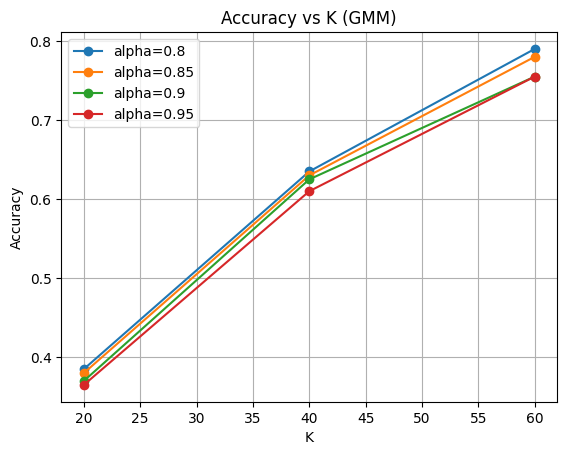

In [19]:
plt.figure()

for alpha in alphas:
    ks = []
    accs = []

    for K in K_VALUES:
        ks.append(K)
        accs.append(gmm_results[alpha][K]["train_acc"])

    plt.plot(ks, accs, marker='o', label=f'alpha={alpha}')

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K (GMM)")
plt.legend()
plt.grid(True)
plt.show()

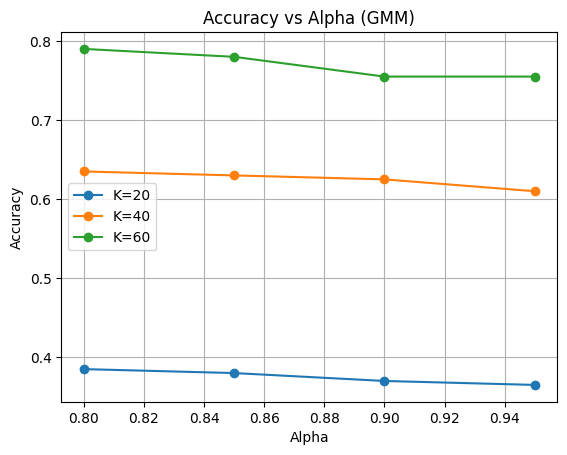

In [20]:
plt.figure()

for K in K_VALUES:
    alphas_list = []
    accs = []

    for alpha in alphas:
        alphas_list.append(alpha)
        accs.append(gmm_results[alpha][K]["train_acc"])

    plt.plot(alphas_list, accs, marker='o', label=f'K={K}')

plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Alpha (GMM)")
plt.legend()
plt.grid(True)
plt.show()

---
## Evaluation on Test Set

Find the best K-Means and GMM models (highest training accuracy), then evaluate on the **test set**.

### Best K-Means on Test Set

In [21]:
print(f"\nBest K-Means: alpha={best_km_alpha}, K={best_km_K}, train_acc={best_km_acc:.4f}")

# Re-fit with fixed seed for reproducibility
centroids_best, _ = kmeans_fit(
    projections[best_km_alpha]['train'],
    best_km_K,
    random_state=SEED
)

# Predict test clusters
km_test_labels = kmeans_predict(
    projections[best_km_alpha]['test'],
    centroids_best
)

# Build mapping on TRAIN set
km_train_labels_best, _ = kmeans_fit(
    projections[best_km_alpha]['train'], best_km_K, random_state=SEED
), None
km_train_labels_best = kmeans_predict(
    projections[best_km_alpha]['train'], centroids_best
)
km_mapping = map_clusters_to_labels(y_train, km_train_labels_best, best_km_K)

# Mapped predictions
km_y_pred = np.array([km_mapping.get(lbl, -1) for lbl in km_test_labels])

km_acc           = accuracy_score(y_test, km_y_pred)
km_f1_macro      = f1_score(y_test, km_y_pred, average='macro',    zero_division=0)
km_f1_weighted   = f1_score(y_test, km_y_pred, average='weighted', zero_division=0)

print(f"KMeans Test Accuracy  : {km_acc:.4f}")
print(f"KMeans Test F1 Macro  : {km_f1_macro:.4f}")
print(f"KMeans Test F1 Weighted: {km_f1_weighted:.4f}")



Best K-Means: alpha=0.8, K=60, train_acc=0.8200
KMeans Test Accuracy  : 0.7950
KMeans Test F1 Macro  : 0.7697
KMeans Test F1 Weighted: 0.7697


### Best GMM on Test Set

In [22]:
print(f"\nBest GMM: alpha={best_gmm_alpha}, K={best_gmm_K}, train_acc={best_gmm_acc:.4f}")

X_tr = projections[best_gmm_alpha]['train']
X_te = projections[best_gmm_alpha]['test']

# Re-fit GMM on training set
mu, sigma, pi, gmm_train_labels = gmm(X_tr, best_gmm_K)

# Build mapping from TRAIN clusters (avoids leakage)
gmm_mapping = map_clusters_to_labels(y_train, gmm_train_labels, best_gmm_K)

# Predict test clusters
gmm_test_labels = predict_gmm(X_te, mu, sigma, pi)

# Mapped predictions
gmm_test_preds = np.array([gmm_mapping.get(lbl, -1) for lbl in gmm_test_labels])

gmm_acc          = accuracy_score(y_test, gmm_test_preds)
gmm_f1_macro     = f1_score(y_test, gmm_test_preds, average='macro',    zero_division=0)
gmm_f1_weighted  = f1_score(y_test, gmm_test_preds, average='weighted', zero_division=0)

print(f"GMM Test Accuracy  : {gmm_acc:.4f}")
print(f"GMM Test F1 Macro  : {gmm_f1_macro:.4f}")
print(f"GMM Test F1 Weighted: {gmm_f1_weighted:.4f}")



Best GMM: alpha=0.8, K=60, train_acc=0.7900
GMM Test Accuracy  : 0.7150
GMM Test F1 Macro  : 0.6940
GMM Test F1 Weighted: 0.6940


### Confusion Matrices

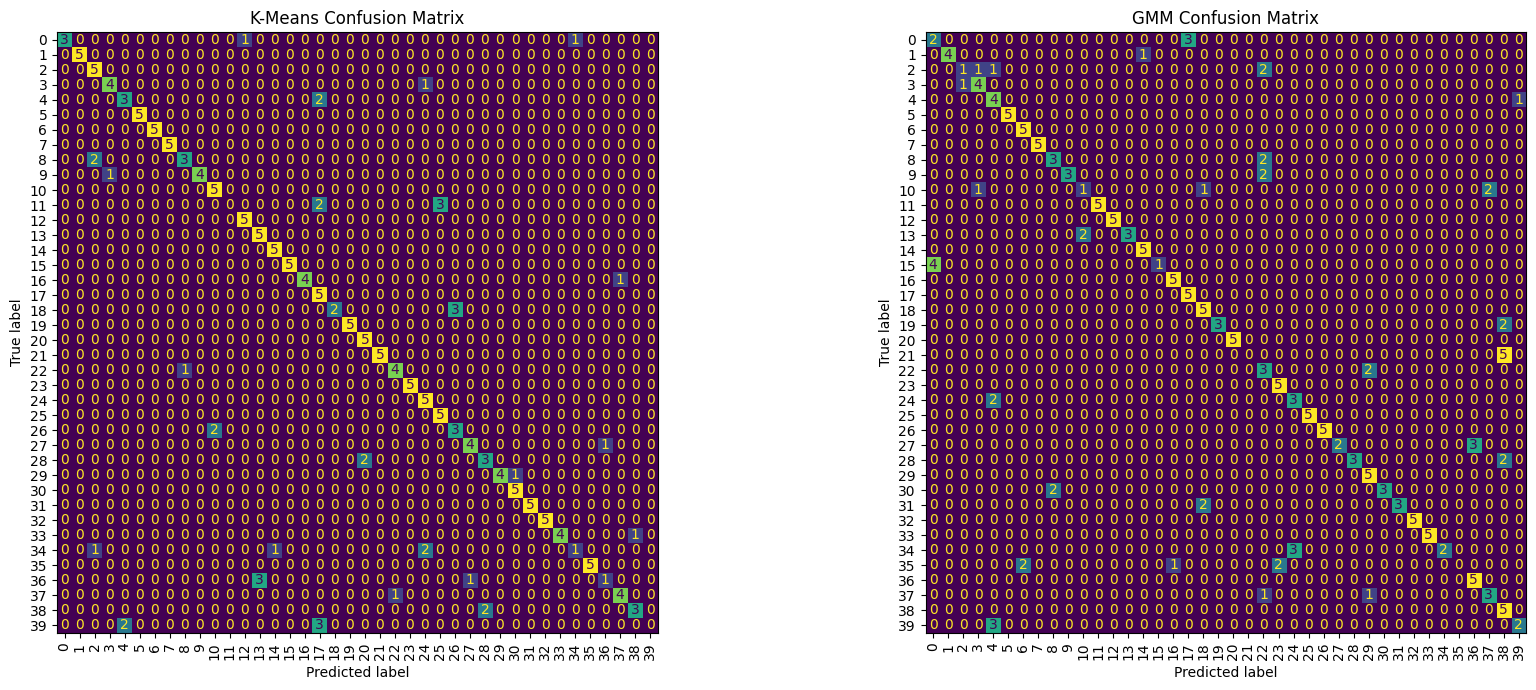

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

models = [
    (km_y_pred, "K-Means"),
    (gmm_test_preds, "GMM")
]

for ax, (y_pred, title) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(
        ax=ax,
        colorbar=False,
        xticks_rotation=90
    )
    ax.set_title(f"{title} Confusion Matrix")

plt.tight_layout()
plt.show()

### Final Comparison Table

In [24]:
print(f"{'Model':<12} {'α':<6} {'K':<6} {'Accuracy':<10} {'F1 Macro':<12} {'F1 Weighted':<12}")
print("-" * 75)
print(f"{'K-Means':<12} "
      f"{best_km_alpha:<6.2f} "
      f"{best_km_K:<6d} "
      f"{km_acc:<10.4f} "
      f"{km_f1_macro:<12.4f} "
      f"{km_f1_weighted:<12.4f}")

print(f"{'GMM':<12} "
      f"{best_gmm_alpha:<6.2f} "
      f"{best_gmm_K:<6d} "
      f"{gmm_acc:<10.4f} "
      f"{gmm_f1_macro:<12.4f} "
      f"{gmm_f1_weighted:<12.4f}")


Model        α      K      Accuracy   F1 Macro     F1 Weighted 
---------------------------------------------------------------------------
K-Means      0.80   60     0.7950     0.7697       0.7697      
GMM          0.80   60     0.7150     0.6940       0.6940      


# Bonus Part

In [42]:
LATENT_DIM = 64
INPUT_DIM  = X_train.shape[1]

# Normalise to [0, 1]
X_tr_norm = X_train / 255.0
X_te_norm = X_test  / 255.0

# Build Autoencoder
inp       = Input(shape=(INPUT_DIM,))
encoded   = Dense(256, activation='relu')(inp)
encoded   = Dense(128, activation='relu')(encoded)
latent    = Dense(LATENT_DIM, activation='relu')(encoded)   # bottleneck

decoded   = Dense(128, activation='relu')(latent)
decoded   = Dense(256, activation='relu')(decoded)
out       = Dense(INPUT_DIM, activation='sigmoid')(decoded)

autoencoder = Model(inp, out)
encoder     = Model(inp, latent)

autoencoder.compile(optimizer=Adam(1e-3), loss='mse')
autoencoder.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 10304)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │     2,638,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10304)          │     2,648,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,368,704 (20.48 MB)

 Trainable params: 5,368,704 (20.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - loss: 0.0369 - val_loss: 0.0285
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0258 - val_loss: 0.0268
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - loss: 0.0249 - val_loss: 0.0240
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 0.0238 - val_loss: 0.0235
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 247ms/step - loss: 0.0233 - val_loss: 0.0231
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - loss: 0.0229 - val_loss: 0.0226
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - loss: 0.0221 - val_loss: 0.0211
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - loss: 0.0204 - val_loss: 0.0200
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - loss: 0.0197 - val_loss: 0.0196
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - loss: 0.0191 - val_loss: 0.0190
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - loss: 0.0188 - val_loss: 0.0188
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - loss: 0.01

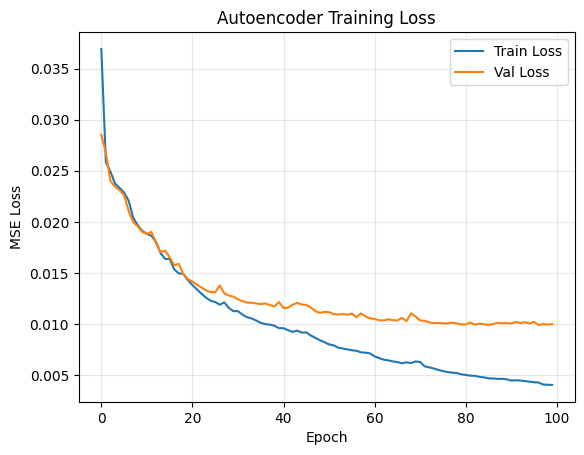

In [43]:
history = autoencoder.fit(
    X_tr_norm, X_tr_norm,
    epochs=100,
    batch_size=32,
    shuffle=True,
    validation_data=(X_te_norm, X_te_norm),
    verbose=1
)

plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [44]:
Z_train = encoder.predict(X_tr_norm)
Z_test  = encoder.predict(X_te_norm)
print(f"Latent train shape: {Z_train.shape}")
print(f"Latent test  shape: {Z_test.shape}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Latent train shape: (200, 64)
Latent test  shape: (200, 64)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


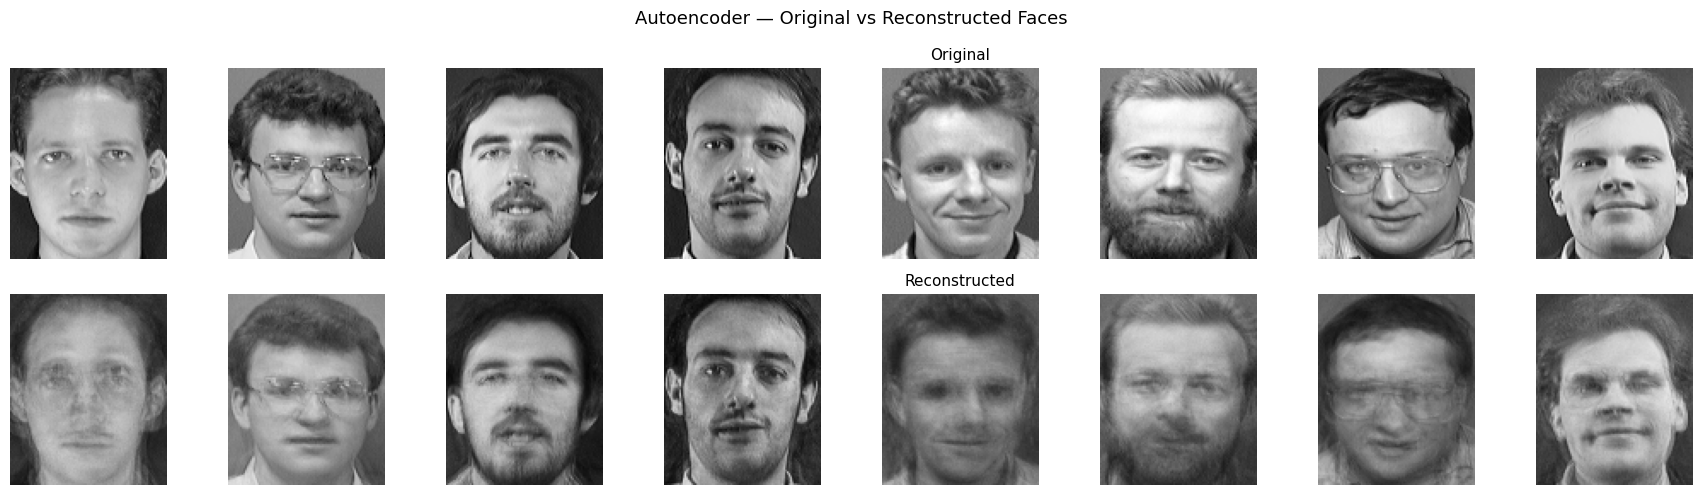

In [53]:
N_SHOW = 8
n = X_tr_norm.shape[0]

sample_idx = [i * (n // N_SHOW) for i in range(N_SHOW)]
fig, axes = plt.subplots(2, N_SHOW, figsize=(2.2 * N_SHOW, 5))

for col, idx in enumerate(sample_idx):
    orig = X_tr_norm[idx]
    rec = autoencoder.predict(orig[np.newaxis, :])[0]

    axes[0, col].imshow(orig.reshape(112, 92), cmap='gray')
    axes[0, col].axis('off')

    if col == 0:
        axes[0, col].set_ylabel("Original", fontsize=10)

    axes[1, col].imshow(rec.reshape(112, 92), cmap='gray', vmin=0, vmax=1)
    axes[1, col].axis('off')

    if col == 0:
        axes[1, col].set_ylabel("Reconstructed", fontsize=10)

axes[0, N_SHOW//2].set_title("Original", fontsize=11)
axes[1, N_SHOW//2].set_title("Reconstructed", fontsize=11)

plt.suptitle("Autoencoder — Original vs Reconstructed Faces", fontsize=13)
plt.tight_layout()
plt.show()

Apply K-means on latent space

In [45]:
ae_km_results = []

for K in K_VALUES:
    np.random.seed(42)
    centroids, labels = kmeans_fit(Z_train, K)
    acc = clustering_accuracy(y_train, labels)
    ae_km_results.append((K, acc, centroids))
    print(f"K={K}  acc={acc:.4f}")


K=20  acc=0.4200
K=40  acc=0.6400
K=60  acc=0.7500


Apply GMM on latent space

In [46]:
ae_gmm_results = []

for K in K_VALUES:
    mu, sigma, pi, labels = gmm(Z_train, K)
    acc = clustering_accuracy(y_train, labels)
    ae_gmm_results.append((K, acc, mu, sigma, pi))
    print(f"K={K}  acc={acc:.4f}")


K=20  acc=0.3850
K=40  acc=0.6250
K=60  acc=0.7650


In [47]:
# Select best AE + K-Means model
best_ae_km  = max(ae_km_results,  key=lambda x: x[1])   # (K, acc, centroids)
best_ae_gmm = max(ae_gmm_results, key=lambda x: x[1])   # (K, acc, mu, sigma, pi)
print(f"Best AE K-Means: K={best_ae_km[0]}, train_acc={best_ae_km[1]:.4f}")
print(f"Best AE GMM   : K={best_ae_gmm[0]}, train_acc={best_ae_gmm[1]:.4f}")


Best AE K-Means: K=60, train_acc=0.7500
Best AE GMM   : K=60, train_acc=0.7650


In [48]:
ae_km_train_clusters = kmeans_predict(Z_train, best_ae_km[2])
ae_km_mapping        = map_clusters_to_labels(y_train, ae_km_train_clusters, best_ae_km[0])

ae_km_test_clusters  = kmeans_predict(Z_test, best_ae_km[2])
ae_km_pred           = np.array([ae_km_mapping.get(c, -1) for c in ae_km_test_clusters])

ae_km_acc        = accuracy_score(y_test, ae_km_pred)
ae_km_f1_mac     = f1_score(y_test, ae_km_pred, average='macro',    zero_division=0)
ae_km_f1_wt      = f1_score(y_test, ae_km_pred, average='weighted', zero_division=0)



ae_gmm_train_clusters = gmm(Z_train, best_ae_gmm[0])[3]
ae_gmm_mapping        = map_clusters_to_labels(y_train, ae_gmm_train_clusters, best_ae_gmm[0])

ae_gmm_test_clusters  = predict_gmm(Z_test, best_ae_gmm[2], best_ae_gmm[3], best_ae_gmm[4])
ae_gmm_pred           = np.array([ae_gmm_mapping.get(c, -1) for c in ae_gmm_test_clusters])

ae_gmm_acc       = accuracy_score(y_test, ae_gmm_pred)
ae_gmm_f1_mac    = f1_score(y_test, ae_gmm_pred, average='macro',    zero_division=0)
ae_gmm_f1_wt     = f1_score(y_test, ae_gmm_pred, average='weighted', zero_division=0)

print(f"AE + K-Means  K={best_ae_km[0]}   acc={ae_km_acc:.4f}  F1 macro={ae_km_f1_mac:.4f}  F1 weighted={ae_km_f1_wt:.4f}")
print(f"AE + GMM      K={best_ae_gmm[0]}  acc={ae_gmm_acc:.4f}  F1 macro={ae_gmm_f1_mac:.4f}  F1 weighted={ae_gmm_f1_wt:.4f}")


AE + K-Means  K=60   acc=0.6900  F1 macro=0.6517  F1 weighted=0.6517
AE + GMM      K=60  acc=0.6450  F1 macro=0.6324  F1 weighted=0.6324


In [49]:
print(f"{'Model':<20} {'Dim':<8} {'K':<6} {'Accuracy':<12} {'F1 Macro':<12} {'F1 Weighted'}")
print("-" * 70)
print(f"{'PCA + K-Means':<20} {k_per_alpha[best_km_alpha]:<8} {best_km_K:<6} {km_acc:<12.4f} {km_f1_macro:<12.4f} {km_f1_weighted:.4f}")
print(f"{'PCA + GMM':<20} {k_per_alpha[best_gmm_alpha]:<8} {best_gmm_K:<6} {gmm_acc:<12.4f} {gmm_f1_macro:<12.4f} {gmm_f1_weighted:.4f}")
print(f"{'AE  + K-Means':<20} {LATENT_DIM:<8} {best_ae_km[0]:<6} {ae_km_acc:<12.4f} {ae_km_f1_mac:<12.4f} {ae_km_f1_wt:.4f}")
print(f"{'AE  + GMM':<20} {LATENT_DIM:<8} {best_ae_gmm[0]:<6} {ae_gmm_acc:<12.4f} {ae_gmm_f1_mac:<12.4f} {ae_gmm_f1_wt:.4f}")


Model                Dim      K      Accuracy     F1 Macro     F1 Weighted
----------------------------------------------------------------------
PCA + K-Means        36       60     0.7950       0.7697       0.7697
PCA + GMM            36       60     0.7150       0.6940       0.6940
AE  + K-Means        64       60     0.6900       0.6517       0.6517
AE  + GMM            64       60     0.6450       0.6324       0.6324
